### **Лабороторная работа №3**

Подготовить jupyter-ноутбук с описанием решения. Просьба подробно всё пояснять с комментариями и выводами.

1. Взять стандартную архитектуру ResNet (например, ResNet18 или ResNet34)

2. Обучить ее на выбранном Вами датасете (например, можете взять датасет со спортивными трансляциями).

Учить с нуля не нужно, достаточно потюнить полносвязный слой.

3. Модифицировать encoder ResNet-а, добавив в него механизм Self-Attention

4. Обучить модифицированную архитектуру с Self-Attention на этом же датасете.

5. Сравнить две модели на тестовой выборке из датасета. Параметры тестирования и сиды необходимо закрепить для проведения корректного сравнения. Составить таблицу с результами. Добавить выводы.

Для работы будем использовать датасет Sports Image Classification с Kaggle. Набор данных содержит изображения, принадлежащие следующим спортивным классам: крикет, борьба, теннис, бадминтон, футбол, плавание и каратэ.

In [1]:
import kagglehub

path = kagglehub.dataset_download("sidharkal/sports-image-classification")

print("Path to dataset files:", path)

100%|██████████| 826M/826M [00:10<00:00, 81.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sidharkal/sports-image-classification/versions/1


In [30]:
# Импортируем необходимые для работы библиотеки
from glob import glob
import numpy as np
import pandas as pd
import os
import random
import seaborn as sns
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import copy
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [3]:
# Закрепим seed для воспроизводимости результатов
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [4]:
# Установим device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


Изучим подробнее информацию о датасете

In [5]:
dataset_path = os.path.join(path, "dataset")
print(os.listdir(dataset_path))

['test.csv', 'train.csv', 'sample_submission.csv', 'test', 'train']


In [6]:
train_df = pd.read_csv(os.path.join(dataset_path, "train.csv"))
train_df.head()

,image_ID,label
0,7c225f7b61.jpg,Badminton
1,b31.jpg,Badminton
2,acb146546c.jpg,Badminton
3,0e62f4d8f2.jpg,Badminton
4,cfd2c28c74.jpg,Cricket


In [7]:
classes = sorted(train_df["label"].unique())
print(classes)

['Badminton', 'Cricket', 'Karate', 'Soccer', 'Swimming', 'Tennis', 'Wrestling']


In [8]:
class_counts = train_df["label"].value_counts()
print(class_counts)

label
Cricket      1556
Wrestling    1471
Tennis       1445
Badminton    1394
Soccer       1188
Swimming      595
Karate        578
Name: count, dtype: int64


Датасет содержит 7 классов спортивных изображений.

Анализ распределения классов показал наличие умеренного дисбаланса данных: классы Swimming и Karate представлены значительно меньшим количеством изображений по сравнению с Cricket и Wrestling.

Посмотрим несколько случайных изображений

In [9]:
images_dir = os.path.join(dataset_path, "train")

In [10]:
img_name = train_df.iloc[0]["image_ID"]
img_path = os.path.join(images_dir, img_name)

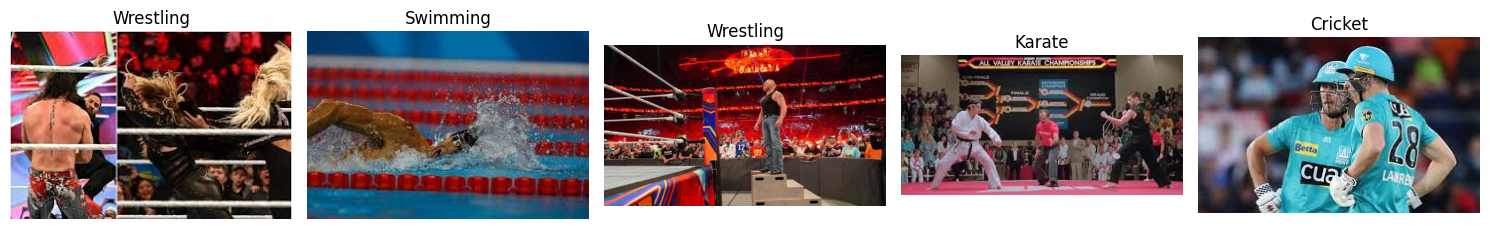

In [11]:
num_samples = 5
fig = plt.figure(figsize=(15, 5))

for i in range(num_samples):
    idx = np.random.randint(0, len(train_df))

    img_name = train_df.iloc[idx]["image_ID"]
    label = train_df.iloc[idx]["label"]

    img_path = os.path.join(images_dir, img_name)
    img = Image.open(img_path)

    ax = fig.add_subplot(1, num_samples, i + 1)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# создаём PyTorch Dataset
class SportsDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.classes = sorted(dataframe["label"].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_name = row["image_ID"]
        label = row["label"]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_idx = self.class_to_idx[label]

        if self.transform:
            image = self.transform(image)

        return image, label_idx

In [13]:
# Делим данные на train и test выборки
train_data, test_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df["label"])

In [14]:
# Определим трансформации
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

In [15]:
# Создаем train_dataset и test_dataset
train_dataset = SportsDataset(
    dataframe=train_data,
    img_dir=images_dir,
    transform=train_transforms)

test_dataset = SportsDataset(
    dataframe=test_data,
    img_dir=images_dir,
    transform=test_transforms)

In [16]:
print("Размер тренировочного датасета:", len(train_dataset))
print("Размер тестового датасета:", len(test_dataset))

Размер тренировочного датасета: 6581
Размер тестового датасета: 1646


In [17]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 3


После применения трансформаций изображения имеют размерность 3×224×224, что соответствует входному формату ResNet18.

Метки классов были успешно преобразованы в числовые индексы для дальнейшего обучения модели.

In [18]:
# Зададим размер батча
batch_size = 16

# Определим даталоадеры, они необходимы для создания батчей из данных
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=batch_size,shuffle=False, num_workers=2, pin_memory=True)

In [19]:
# Получим один батч тренировочных данных
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])


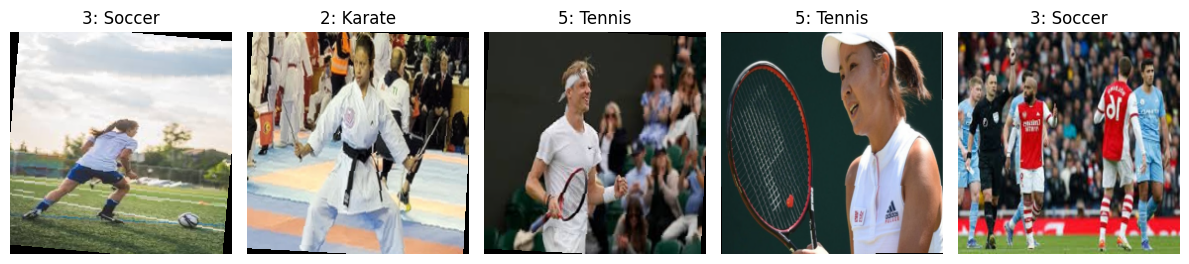

In [20]:
# Визуализация нескольких изображений
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

fig = plt.figure(figsize=(12, 5))

for i in range(5):
    ax = fig.add_subplot(1, 5, i + 1)
    img = images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)

    class_name = idx_to_class[labels[i].item()]
    ax.set_title(f"{labels[i].item()}: {class_name}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Загружаем ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


In [22]:
# Замораживаем все слои (encoder)
for param in model.parameters():
    param.requires_grad = False

# Меняем последний слой под нашу задачу (7 классов)
num_features = model.fc.in_features
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(num_features, num_classes)

# Переносим модель на device
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
# Loss optimizer
criterion = nn.CrossEntropyLoss()

# Обучаем только последний слой
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

In [24]:
EPOCHS = 30

best_test_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Train
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Test
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / len(test_loader)
    test_acc = correct / total

    # Сохраняем лучшую модель
    if test_acc > best_test_acc:
          best_test_acc = test_acc
          best_model_wts = copy.deepcopy(model.state_dict())

          torch.save(model.state_dict(), "best_resnet18.pth")
          print("Лучшая модель сохранена!")

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
    print(f"Best Test Acc so far: {best_test_acc:.4f}")

model.load_state_dict(best_model_wts)
print("Лучшая модель загружена.")


Epoch 1/30


100%|██████████| 412/412 [00:47<00:00,  8.59it/s]


Лучшая модель сохранена!
Train Loss: 0.9869 | Train Acc: 0.6744
Test  Loss: 0.5470 | Test  Acc: 0.8226
Best Test Acc so far: 0.8226

Epoch 2/30


100%|██████████| 412/412 [00:47<00:00,  8.71it/s]


Train Loss: 0.6520 | Train Acc: 0.7851
Test  Loss: 0.5273 | Test  Acc: 0.8177
Best Test Acc so far: 0.8226

Epoch 3/30


...

Train Loss: 0.4096 | Train Acc: 0.8537
Test  Loss: 0.4035 | Test  Acc: 0.8584
Best Test Acc so far: 0.8913

Epoch 29/30


100%|██████████| 412/412 [00:47<00:00,  8.71it/s]


Train Loss: 0.4238 | Train Acc: 0.8491
Test  Loss: 0.3940 | Test  Acc: 0.8584
Best Test Acc so far: 0.8913

Epoch 30/30


100%|██████████| 412/412 [00:45<00:00,  9.00it/s]


Train Loss: 0.4148 | Train Acc: 0.8538
Test  Loss: 0.3386 | Test  Acc: 0.8852
Best Test Acc so far: 0.8913
Лучшая модель загружена.


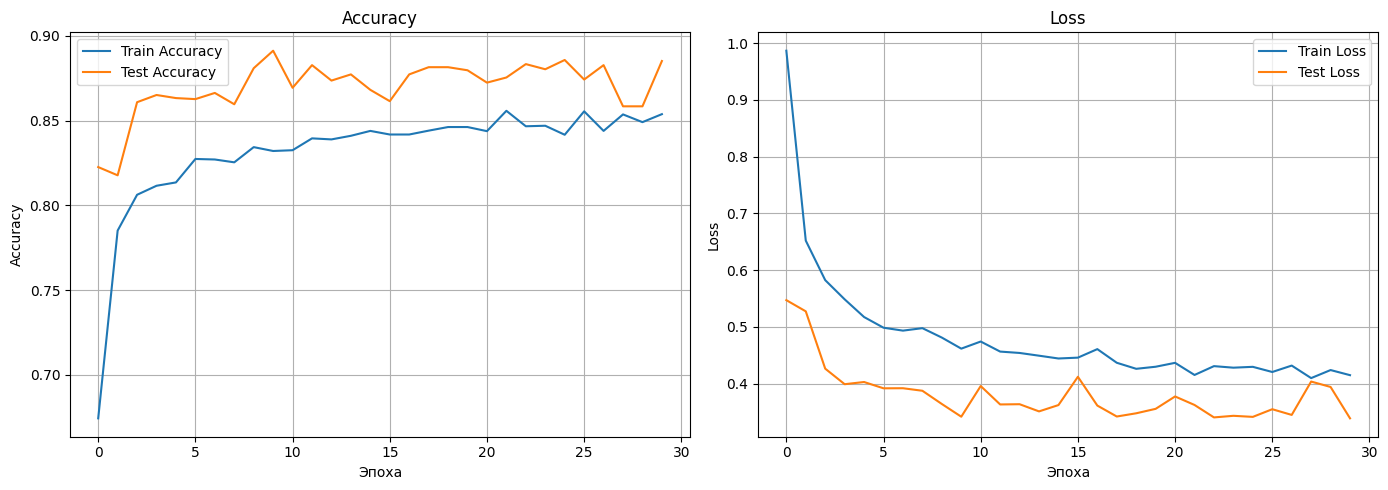

In [25]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.title("Accuracy")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Loss (справа)
plt.subplot(1, 2, 2)

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.title("Loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Полученные результаты свидетельствуют о том, что модель ResNet18 успешно сошлась на рассматриваемом датасете.
В процессе обучения наблюдалось постепенное уменьшение значения функции потерь и рост accuracy как на обучающей, так и на тестовой выборке.

Наилучшее качество модели было достигнуто примерно после 10-й эпохи, после чего улучшение метрик стало незначительным, модель вышла на плато. Также можно отметить отсутствие выраженного переобучения: значения accuracy и loss на train и test выборках изменялись согласованно.

Полученный результат baseline-модели составил около 89% accuracy на тестовой выборке.

In [28]:
# Построим classification report
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes))

              precision    recall  f1-score   support

   Badminton       0.85      0.92      0.88       279
     Cricket       0.93      0.86      0.90       311
      Karate       0.92      0.77      0.84       116
      Soccer       0.83      0.87      0.85       238
    Swimming       0.96      0.92      0.94       119
      Tennis       0.84      0.85      0.85       289
   Wrestling       0.93      0.95      0.94       294

    accuracy                           0.89      1646
   macro avg       0.89      0.88      0.88      1646
weighted avg       0.89      0.89      0.89      1646



Анализируя полученные результаты, можно отметить, что модель демонстрирует высокое качество классификации для большинства классов спортивных изображений.

Наилучшие результаты были получены для классов Swimming и Wrestling, где значение F1-score достигло 0.94.

Наиболее сложным для классификации оказался класс Karate, для которого recall оказался ниже по сравнению с остальными классами. Вероятно, это связано с меньшим количеством изображений в датасете и возможным визуальным сходством с другими спортивными категориями.

Значения macro average и weighted average оказались близкими друг к другу, это говорит об отсутствии сильной деградации качества на менее представленных классах несмотря на умеренный дисбаланс данных.

Теперь добавим механизм Self-Attention и посмотрим, какие результаты получатся.

In [31]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super(SelfAttention, self).__init__()
        self.query = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.key = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.value = nn.Conv2d(in_dim, in_dim, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        batch_size, C, width, height = x.size()

        # Query
        proj_query = self.query(x).view(batch_size, -1, width * height)
        proj_query = proj_query.permute(0, 2, 1)

        # Key
        proj_key = self.key(x).view(batch_size, -1, width * height)

        # Attention map
        energy = torch.bmm(proj_query, proj_key)
        attention = self.softmax(energy)

        # Value
        proj_value = self.value(x).view(batch_size, -1, width * height)

        out = torch.bmm(
            proj_value,
            attention.permute(0, 2, 1))

        out = out.view(batch_size, C, width, height)

        # Residual connection
        out = self.gamma * out + x

        return out

In [32]:
class ResNet18WithAttention(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18WithAttention, self).__init__()

        # Загружаем pretrained ResNet18
        self.resnet = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT)

        # Замораживаем encoder
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Удаляем FC слой
        self.features = nn.Sequential(
            *list(self.resnet.children())[:-2])

        # Self-Attention block
        self.attention = SelfAttention(in_dim=512)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [33]:
# Создаём модель
attention_model = ResNet18WithAttention(num_classes=len(train_dataset.classes))

# Переносим на device
attention_model = attention_model.to(device)

print(attention_model)

ResNet18WithAttention(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [34]:
# Loss
criterion = nn.CrossEntropyLoss()

# Обучаем attention и classifier
optimizer = optim.Adam([{"params": attention_model.attention.parameters()},
        {"params": attention_model.fc.parameters()}], lr=1e-3)

In [35]:
EPOCHS = 30

best_attention_acc = 0.0
best_attention_wts = copy.deepcopy(attention_model.state_dict())

attention_train_losses = []
attention_test_losses = []

attention_train_accs = []
attention_test_accs = []

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Train
    attention_model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = attention_model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Test
    attention_model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_attention_preds = []
    all_attention_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = attention_model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_attention_preds.extend(preds.cpu().numpy())
            all_attention_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / len(test_loader)
    test_acc = correct / total


    # Сохраняем лучшую модель
    if test_acc > best_attention_acc:

        best_attention_acc = test_acc

        best_attention_wts = copy.deepcopy(attention_model.state_dict())

        torch.save(attention_model.state_dict(),"best_attention_resnet18.pth")

        print("Лучшая Attention модель сохранена!")

    attention_train_losses.append(train_loss)
    attention_test_losses.append(test_loss)

    attention_train_accs.append(train_acc)
    attention_test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
    print(f"Best Attention Acc: {best_attention_acc:.4f}")

attention_model.load_state_dict(best_attention_wts)
print("Лучшая Attention модель загружена.")


Epoch 1/30


100%|██████████| 412/412 [00:46<00:00,  8.90it/s]


Лучшая Attention модель сохранена!
Train Loss: 0.8940 | Train Acc: 0.6883
Test  Loss: 0.5307 | Test  Acc: 0.8159
Best Attention Acc: 0.8159

Epoch 2/30


100%|██████████| 412/412 [00:47<00:00,  8.63it/s]


Лучшая Attention модель сохранена!
Train Loss: 0.6080 | Train Acc: 0.7898
Test  Loss: 0.5003 | Test  Acc: 0.8165
Best Attention Acc: 0.8165

Epoch 3/30


...

Train Loss: 0.3865 | Train Acc: 0.8654
Test  Loss: 0.3796 | Test  Acc: 0.8718
Best Attention Acc: 0.8919

Epoch 29/30


100%|██████████| 412/412 [00:47<00:00,  8.75it/s]


Train Loss: 0.3690 | Train Acc: 0.8696
Test  Loss: 0.3551 | Test  Acc: 0.8846
Best Attention Acc: 0.8919

Epoch 30/30


100%|██████████| 412/412 [00:47<00:00,  8.70it/s]


Лучшая Attention модель сохранена!
Train Loss: 0.3850 | Train Acc: 0.8631
Test  Loss: 0.3392 | Test  Acc: 0.8949
Best Attention Acc: 0.8949
Лучшая Attention модель загружена.


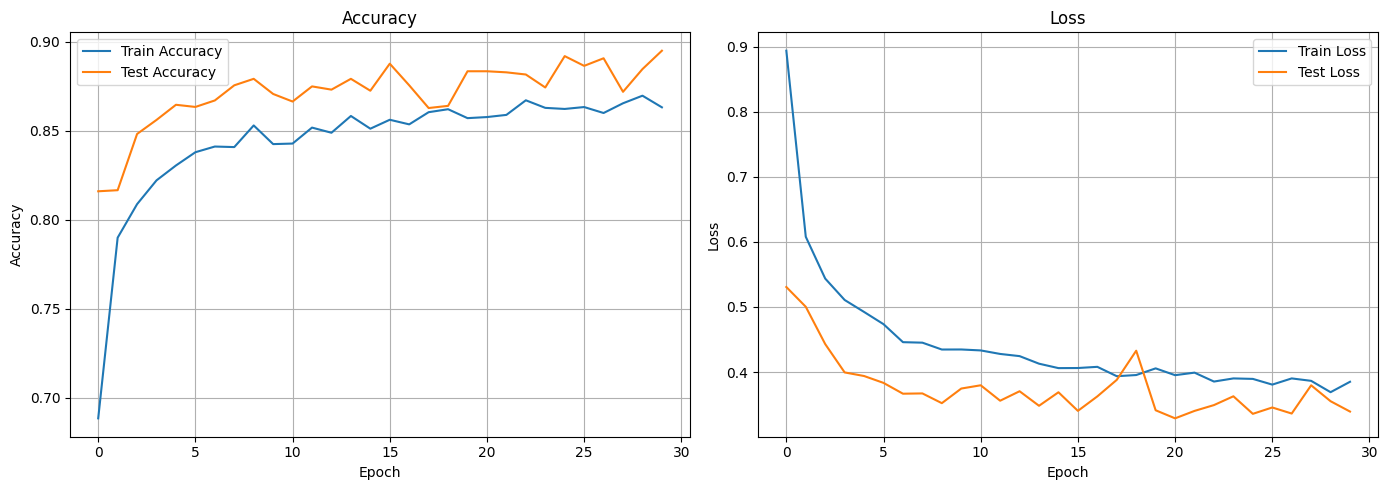

In [39]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(attention_train_accs, label="Train Accuracy")
plt.plot(attention_test_accs, label="Test Accuracy")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# Loss
plt.subplot(1, 2, 2)

plt.plot(attention_train_losses, label="Train Loss")
plt.plot(attention_test_losses, label="Test Loss")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Модель ResNet18 с добавлением Self-Attention показала более стабильное обучение и немного лучшие результаты по сравнению с базовой архитектурой.

Наилучшее значение accuracy на тестовой выборке составило около 89.5%, что немного выше результата обычного ResNet18.

Добавление механизма Self-Attention позволило модели лучше учитывать взаимосвязи между признаками на изображении, что положительно сказалось на качестве классификации.

In [40]:
print(classification_report(
    all_attention_labels,
    all_attention_preds,
    target_names=train_dataset.classes))

              precision    recall  f1-score   support

   Badminton       0.93      0.85      0.89       279
     Cricket       0.91      0.90      0.91       311
      Karate       0.75      0.90      0.82       116
      Soccer       0.91      0.87      0.89       238
    Swimming       0.91      0.95      0.93       119
      Tennis       0.85      0.89      0.87       289
   Wrestling       0.94      0.94      0.94       294

    accuracy                           0.89      1646
   macro avg       0.89      0.90      0.89      1646
weighted avg       0.90      0.89      0.90      1646



Модель ResNet18 с добавлением Self-Attention показала стабильные результаты на тестовой выборке с общей точностью около 89%.

Значения Macro F1 и Weighted F1 близки, что говорит об отсутствии сильного перекоса в сторону доминирующих классов и достаточно равномерном качестве предсказаний.

Наиболее уверенно модель распознаёт классы Wrestling, Swimming и Cricket, в то время как класс Karate остаётся наиболее сложным и характеризуется сниженной точностью.


**Сравнение моделей на тестовой выборке из датасета**

In [41]:
results = pd.DataFrame({
    "Model": ["ResNet18", "ResNet18 + Self-Attention"],
    "Test Accuracy": [0.8913, 0.8949],
    "Macro F1": [0.88, 0.89],
    "Weighted F1": [0.89, 0.90]})

results

,Model,Test Accuracy,Macro F1,Weighted F1
0,ResNet18,0.8913,0.88,0.89
1,ResNet18 + Self-Attention,0.8949,0.89,0.90


**Вывод:** На тестовой выборке обе модели демонстрируют высокое и достаточно близкое качество.

Базовая модель ResNet18 показывает стабильный результат с accuracy около 0.89. При добавлении механизма Self-Attention наблюдается небольшое, но устойчивое улучшение качества: accuracy увеличивается до примерно 0.895, а также фиксируется рост значений macro F1-score и weighted F1-score.

Улучшение наблюдается не только по общей точности, но и по более сбалансированным метрикам качества. Это критично в условиях умеренного дисбаланса классов, который присутствует в датасете (например, классы Swimming и Karate представлены меньшим количеством изображений). Self-Attention помогает модели лучше фокусироваться на наиболее информативных областях изображения, снижая влияние фоновых и нерелевантных признаков.

Таким образом, можно сделать вывод, что внедрение Self-Attention в архитектуру ResNet18 приводит к небольшому, но систематическому улучшению качества классификации, особенно в части обобщающей способности и баланса между классами. При этом базовая архитектура уже обеспечивает сильный baseline, а attention-механизм выступает как дополнительное улучшение, повышающее устойчивость модели.